# Plot epsilon and mu over a user given frequency range for a selected material

This notebook asks the user for the material, lower frequency range, and upper frequency range, then scrubs each section of the pdf until it finds a material match, then finds epsilon, mu, and plots them.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pdfplumber
import os
import re

Now, the appropriate functions are defined (parsecomplexsafe, getfreq)

In [16]:
# Parse complex safe
def parse_complex_safe(s):
    """
    Parse a string from a PDF table into a complex number.
    Handles weird cases like '1.6503+', '2.34- 0.56i', etc.
    """
    if s is None:
        return complex(0, 0)
    
    s = s.strip()  # remove leading/trailing whitespace
    s = s.replace(" ", "")  # remove internal spaces
    s = s.replace('\n', '') # remove internal line breaks
    s = s.replace("i", "j")  # Python uses j for imaginary unit
    s = s.replace('–', '-') # adjusts dash type (em to en)

    # Fix cases where string ends with + or - (incomplete imaginary part)
    if re.match(r"^[+-]?[\d.]+[+-]$", s):
        s += "0j"  # add 0 as imaginary part
    
    # Fix cases where string is just a real number with trailing j
    if re.match(r"^[+-]?[\d.]+$", s):
        s += "+0j"

    try:
        c = complex(s)
    except ValueError:
        # fallback: treat as 0+0j
        c = complex(0, 0)
    return c

In [17]:
# Get frequency range
def get_frequency_range_from_pdf(material, pdf_path):
    '''
    Extracts the frequency range (min, max) for a given material
    from the PDF text.
    '''
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            for line in text.split("\n"):
                if material.lower() in line.lower():
                    # Look for (X–Y GHz) after the material name
                    match = re.search(r"\((\d*\.?\d+)–(\d*\.?\d+)\s*GHz\)", line)
                    if match:
                        f_min = float(match.group(1))
                        f_max = float(match.group(2))
                        return f_min, f_max
    return None, None

Functions for gettting epsilon and mu values for 12_1, 12_4, 12_6, 12_7, 12_8 are defined

Working: 12_1, 12_6, 12_8 (mostly)

Not yet working (error placeholder): 12_4, 12_7

In [18]:
# 12_1
def getEpAndMu_12_1(user_f_min, user_f_max, material):
    base_dir = os.getcwd()

    pdf_path = os.path.join(base_dir, "12_1.pdf")

    rows = []
    
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table:
                rows.extend(table)

    df = pd.DataFrame(rows)

    # find the row index where this sample name appears
    sample_idx = df[df.iloc[:,0].str.contains(material, na=False)].index[0]

    # Get frequency range automatically
    f_min, f_max = get_frequency_range_from_pdf(material, pdf_path)
    if f_min is None or f_max is None:
        # raise ValueError(f"Could not find frequency range for {material}")
        f_min = 0.2
        f_max = 250
        print('Low and high frequncies not found, defaulting to 0.2-250GHz')
    user_f_min = float(user_f_min)
    user_f_max = float(user_f_max)
    
    if user_f_min < f_min or user_f_max > f_max:
        print(f"\n\nWARNING: Frequency range {f_min}–{f_max} GHz is defined for {material}. All data outside of this range will be extrapolated.")


    # Row 2 (index=2) has B, C, D, G, H, I, J
    df.columns = df.iloc[2]

    df = df.drop([0, 1]).reset_index(drop=True)

    # Now df[["B","C","D","G","H","I","J"]] will work
    df_selected = df[["B", "C", "D", "G", "H", "I", "J"]]


    # Apply to the selected row
    real_floats = df_selected.iloc[sample_idx - 1].apply(parse_complex_safe).apply(lambda x: x.real)
    imag_floats = df_selected.iloc[sample_idx].apply(parse_complex_safe).apply(lambda x: x.imag)

    complex_floats = real_floats + imag_floats * complex(0, 1)
    complex_floats.head()

    B = complex_floats.iloc[0]
    C = complex_floats.iloc[1]
    D = complex_floats.iloc[2]
    G = complex_floats.iloc[3]
    H = complex_floats.iloc[4]
    I = complex_floats.iloc[5]
    J = complex_floats.iloc[6]
    
    num_points = 1000  # Number of frequency points
   
    frequencies = np.linspace(user_f_min, user_f_max, num_points)
    epsilon_f = B + 2 * C * (frequencies ** D) + G * (1 - J * (frequencies - H)**2 - 1j * 2 * I * frequencies)**(-1)


    #permeability (mu = 1 for non-farreous)
    mu_f = np.ones(frequencies.shape)

    # loglog plot
    plt.figure()
    plt.loglog(frequencies, np.real(epsilon_f), 'b-', linewidth=2, label='Re($\epsilon$)')
    plt.loglog(frequencies, np.imag(epsilon_f), 'r--', linewidth=2, label='Im($\epsilon$)')
    plt.xlabel('Frequency [GHz]', fontsize=12)
    plt.ylabel('Epsilon', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, which="both", ls="--")
    plt.title('Real and Imaginary Permittivity vs. Frequency', fontsize=14)
    plt.xlim(user_f_min, user_f_max)
    plt.ylim(1e-4, 1e4)
    plt.show()

    # return values
    return(epsilon_f, mu_f)

In [19]:
# 12_4
def getEpAndMu_12_4():
    materials_data = [
        {
            'name': "80 µm 9%/vol in epoxy, 1.38 g/cc",
            'freq_range_ghz': (0.05, 18),
            'chi_m_params': {'B': 0.34, 'C': 1.8694, 'D': 0.8412},
            'eps1_params': None,
            'eps2_params': {'B': 2.47+0.26j, 'C': 8E-02-0.14j, 'D': 0.61+0.68j, 'E': -0.17+0.48j, 'F': 0.66-7E-02j, 'G': 10.66-12.9j, 'H': -18.6+10.47j}
        },
        {
            'name': "80 µm 16%/vol in epoxy, 1.6 g/cc",
            'freq_range_ghz': (0.001, 10),
            'chi_m_params': {'B': 1.16, 'C': 0.6562, 'D': 0.2022},
            'eps1_params': None,
            'eps2_params': {'B': 2.66+0.16j, 'C': 7E-02-9E-02j, 'D': 0.61+0.39j, 'E': 0.26+0.42j, 'F': 0.81+0.12j, 'G': 4.3+10.9j, 'H': 51.6+43.9j}
        },
        {
            'name': "80 µm 16.7%/vol in epoxy, 1.68 g/cc",
            'freq_range_ghz': (0.05, 10),
            'chi_m_params': {'B': 1.23, 'C': 1.499, 'D': 0.583},
            'eps1_params': {'B': 1.57+5E-02j, 'C': 9E-02+0.14j, 'D': -1.7-0.25j, 'E': 1.71+0.12j, 'F': 5E-02-14.7j, 'G': 1.52+43.6j},
            'eps2_params': None
        },
        {
            'name': "80 µm 29.9%/vol in epoxy, 2.22 g/cc (0.05-10 GHz)",
            'freq_range_ghz': (0.05, 10),
            'chi_m_params': {'B': 2.21, 'C': 0.866, 'D': 0.940},
            'eps1_params': None,
            'eps2_params': None
        },
        {
            'name': "80 µm 29.9%/vol in epoxy, 2.22 g/cc (0.001-18 GHz)",
            'freq_range_ghz': (0.001, 18),
            'chi_m_params': {'B': 2.04, 'C': 0.554, 'D': 0.240},
            'eps1_params': {'B': 2.57+0.55j, 'C': 1.46+0.56j, 'D': -3e-3-4e-3j, 'E': -0.44-1.1j, 'F': 20.16+7.5j, 'G': -11.9-73.9j},
            'eps2_params': None
        },
        {
            'name': "80 µm 41.1%/vol in epoxy, 2.68 g/cc",
            'freq_range_ghz': (0.05, 10),
            'chi_m_params': {'B': 4.15, 'C': 0.61, 'D': 0.28},
            'eps1_params': {'B': 1.18+4e-2j, 'C': 1.14+3e-2j, 'D': -9e-2+5e-2j, 'E': 1.26+4e-2j, 'F': 13.8-13.7j, 'G': 6.03+90.4j},
            'eps2_params': None
        },
        {
            'name': "80 µm 49.4%/vol in epoxy, ~3.0 g/cc",
            'freq_range_ghz': (0.001, 10),
            'chi_m_params': {'B': 6.18, 'C': 0.33, 'D': 0.12},
            'eps1_params': {'B': 1.75+7e-2j, 'C': 1.58+0.18j, 'D': -0.23+3e-2j, 'E': 1.85+0.16j, 'F': 14.68-10.64j, 'G': -34.2+15.8j},
            'eps2_params': {'B': 3.23+0.44j, 'C': 7e-2+0.11j, 'D': 0.65+0.42j, 'E': -0.95+0.1j, 'F': 1.96+0.17j, 'G': 7.53-3.33j, 'H': -10.26-4.8j}
        },
        {
            'name': "80 µm 53.6%/vol in epoxy, ~3.2 g/cc",
            'freq_range_ghz': (0.05, 10),
            'chi_m_params': {'B': 4.72, 'C': 0.7178, 'D': 0.3421},
            'eps1_params': {'B': 1.63-2E-02j, 'C': 1.47+7E-02j, 'D': -5E-002-0.17j, 'E': 1.89-2E-002j, 'F': 1.64+13.67j, 'G': 14.2+22.1j},
            'eps2_params': {'B': 3.28+2E-002j, 'C': 0.31-9E-002j, 'D': 0.39+0.3j, 'E': -0.94+0.63j, 'F': 1.72-2E-003j, 'G': 7.89+9.44j, 'H': 6.18-49.19j}
        },
        {
            'name': "80 µm 58.4%/vol in epoxy, ~3.29 g/cc",
            'freq_range_ghz': (0.05, 10),
            'chi_m_params': {'B': 8.86, 'C': 0.34, 'D': 0.12},
            'eps1_params': {'B': 1.2-1.4j, 'C': 1.9-0.98j, 'D': -0.12-0.16j, 'E': 2.05+2.73j, 'F': 7.32-15.6j, 'G': -33.7+20.6j},
            'eps2_params': {'B': 3.49+0.18j, 'C': 0.6-0.16j, 'D': 0.34-3.7E-002j, 'E': -0.74+0.72j, 'F': 2.29+2E-002j, 'G': 2.87+2.01j, 'H': 0.9-2.7j}
        },
        {
            'name': "80 µm 61.4%/vol in epoxy, ~3.52 g/cc",
            'freq_range_ghz': (0.05, 10),
            'chi_m_params': {'B': 10.69, 'C': 0.403, 'D': 0.18},
            'eps1_params': {'B': 1.89-1.31j, 'C': 2.63-0.85j, 'D': -0.12-0.18j, 'E': 2.72+2.88j, 'F': 14.49-13.49j, 'G': -48.4+18.1j},
            'eps2_params': {'B': 3.96+0.33j, 'C': 1.05-0.11j, 'D': 9E-002-0.2j, 'E': -1.02+0.82j, 'F': 2.9+0.4j, 'G': 8.7-2.2j, 'H': -3.12-11.9j}
        },
        {
            'name': "80 µm 61.8%/vol in epoxy, ~3.53 g/cc",
            'freq_range_ghz': (0.05, 10),
            'chi_m_params': {'B': 7.50, 'C': 0.55, 'D': 0.26},
            'eps1_params': {'B': 1.88-1.35j, 'C': 2.1-0.62j, 'D': -8E-002-0.22j, 'E': 2.54+2.62j, 'F': 15.88-23.4j, 'G': -54.1+17.5j},
            'eps2_params': {'B': 3.85+0.25j, 'C': 0.95-0.15j, 'D': 0.33-0.28j, 'E': -1.04+0.65j, 'F': 2.79+0.14j, 'G': 7.3-0.23j, 'H': 1.48-5.1j}
        },
        {
            'name': "80 µm 76.1%/vol in epoxy, ~4.12 g/cc",
            'freq_range_ghz': (0.001, 10),
            'chi_m_params': {'B': 14.20, 'C': 0.18, 'D': 0.053},
            'eps1_params': None,
            'eps2_params': None
        },
        {
            'name': "500-nm Fe 7% + 80-µm Ferrite 7%/vol in epoxy, 1.8 g/cc",
            'freq_range_ghz': (0.001, 18),
            'chi_m_params': {'B': 1.05, 'C': 3.32, 'D': 1.68},
            'eps1_params': {'B': 3.31+0.11j, 'C': 2.32+0.15j, 'D': 5e-3-6e-3j, 'E': 1.87-0.22j, 'F': 12.1-0.76j, 'G': -2.2-19.8j},
            'eps2_params': {'B': 3.93+2e-2j, 'C': 0.97-0.13j, 'D': 3e-2+0.15j, 'E': -0.26+0.32j, 'F': 2.8+0.16j, 'G': 13.1-2.91j, 'H': -11.8-19j}
        },
        {
            'name': "500-nm Fe 10.2% + 80-µm Ferrite 10.1%/vol in epoxy, 2.1 g/cc",
            'freq_range_ghz': (0.001, 10),
            'chi_m_params': {'B': 0.99, 'C': 4.12, 'D': 1.52},
            'eps1_params': {'B': 0.97-1.54j, 'C': 2.29+1.25j, 'D': 0.11-6E-002j, 'E': 2.1+2.69j, 'F': 8.39+13.31j, 'G': 18.7+15.7j},
            'eps2_params': None
        },
        {
            'name': "500-nm Fe 13.4% + 80-µm Ferrite 13.6%/vol in epoxy, 2.43 g/cc",
            'freq_range_ghz': (0.05, 10),
            'chi_m_params': {'B': 3.04, 'C': 1.87, 'D': 0.403},
            'eps1_params': {'B': 1.4+1.37j, 'C': 2.76-1.06j, 'D': 0+2E-002j, 'E': 2.45+2.9j, 'F': 266.8-266.9j, 'G': -24.8-26.1j},
            'eps2_params': {'B': 3.53+0.2j, 'C': 0.92-0.75j, 'D': 0.29+0.14j, 'E': 0.44+4E-002j, 'F': 2.92+0.2j, 'G': 11.6-12j, 'H': -34.8+6.3j}
        },
        {
            'name': "500-nm Fe 17.5% + 80-µm Ferrite 17.5%/vol in epoxy, 2.82 g/cc",
            'freq_range_ghz': (0.05, 10),
            'chi_m_params': {'B': 4.86, 'C': 0.954, 'D': 0.3640},
            'eps1_params': {'B': 2.08-0.82j, 'C': 3.16-0.69j, 'D': 0.28+9E-002j, 'E': 5.78+2.28j, 'F': 4.2+0.3j, 'G': 1.26-2.32j},
            'eps2_params': {'B': 4.3+0.26j, 'C': 1.13-0.86j, 'D': -0.18-0.1j, 'E': 0.57+0.11j, 'F': 3.47+0.25j, 'G': 2-16.1j, 'H': -0.32+22.9j}
        },
        {
            'name': "500-nm Fe 19.9% + 80-µm Ferrite 20.0%/vol in epoxy, 3.1 g/cc",
            'freq_range_ghz': (0.001, 10),
            'chi_m_params': {'B': 8.14, 'C': 0.55, 'D': 0.21},
            'eps1_params': {'B': 2.41-1.8j, 'C': 3.27-1.2j, 'D': 8E-002+0.61j, 'E': 6.13+6.3j, 'F': 1.39+1.64j, 'G': 0.74-0.86j},
            'eps2_params': {'B': 3.67-4E-002j, 'C': 0.75-0.53j, 'D': -0.3-0.4j, 'E': -0.21+0.11j, 'F': 3.05-6E-002j, 'G': 23.64+12.3j, 'H': 16.3+5.2j}
        },
        {
            'name': "500-nm Fe 23.3% + 80-µm Ferrite 23.3%/vol in epoxy, 3.4 g/cc",
            'freq_range_ghz': (0.05, 10),
            'chi_m_params': {'B': 8.41, 'C': 0.525, 'D': 0.19},
            'eps1_params': {'B': 5.41+1.1j, 'C': 4-0.79j, 'D': -2E-003-2.6E-002j, 'E': -0.61+0.7j, 'F': 0.18+0.57j, 'G': 0.12+7E-002j},
            'eps2_params': {'B': 4.48+0.16j, 'C': 1.69-0.46j, 'D': -0.2-7E-002j, 'E': -0.62+0.11j, 'F': 3.65+8E-002j, 'G': 29.6-23.5j, 'H': -115+53.4j}
        },
    ]


    def calculate_chi_m(f, params):
        B, C, D = params['B'], params['C'], params['D']
        j = 1j
        numerator = B * (1 - j * f / D)
        denominator = 1 - (f / C)**2 - (j * f / D)
        return np.divide(numerator, denominator, out=np.zeros_like(denominator, dtype=np.complex128), where=denominator!=0)

    def calculate_epsilon1(f, params):
        """
        Calculates permittivity using the first model (ε1).
        Formula: ε1(f) = B + C*f^D + E / (1 - (f/F)^2 - 2j*(f/G))
        """
        B, C, D, E, F, G = params['B'], params['C'], params['D'], params['E'], params['F'], params['G']
        j = 1j
        f_complex = f.astype(np.complex128)
        term1 = B
        term2 = C * np.power(f_complex, D)
        lorentz_num = E
        lorentz_den = 1 - (f / F)**2 - 2*j * (f / G)
        term3 = np.divide(lorentz_num, lorentz_den, out=np.zeros_like(lorentz_den, dtype=np.complex128), where=lorentz_den!=0)
        return term1 + term2 + term3

    def calculate_epsilon2(f, params):
        """
        Calculates permittivity using the second model (ε2).
        Formula: ε2(f) = B + real(C)*f^D + imag(C)*f^E + F / (1 - (f/G)^2 - 2j*(f/H))
        """
        B, C, D, E, F, G, H = params['B'], params['C'], params['D'], params['E'], params['F'], params['G'], params['H']
        j = 1j
        f_complex = f.astype(np.complex128)
        term1 = B
        term2 = np.real(C) * np.power(f_complex, D)
        term3 = np.imag(C) * np.power(f_complex, E)
        lorentz_num = F
        lorentz_den = 1 - (f / G)**2 - 2*j * (f / H)
        term4 = np.divide(lorentz_num, lorentz_den, out=np.zeros_like(lorentz_den, dtype=np.complex128), where=lorentz_den!=0)
        return term1 + term2 + term3 + term4

    if __name__ == "__main__":
        print("Please select a material from the list:")
        for i, material in enumerate(materials_data):
            print(f"  [{i+1}] {material['name']} (Tested Range: {material['freq_range_ghz'][0]}-{material['freq_range_ghz'][1]} GHz)")

        choice = -1
        while not (1 <= choice <= len(materials_data)):
            try:
                choice = int(input(f"Enter a number (1-{len(materials_data)}): "))
                if not (1 <= choice <= len(materials_data)):
                    print("Invalid choice. Please select a number from the list.")
            except ValueError:
                print("Invalid input. Please enter a number.")

        selected_material = materials_data[choice - 1]

        while True:
            try:
                min_freq_ghz = float(input("Enter the minimum frequency (GHz): "))
                max_freq_ghz = float(input("Enter the maximum frequency (GHz): "))
                if min_freq_ghz >= max_freq_ghz:
                    print("Minimum frequency must be less than maximum frequency.")
                    continue
                break
            except ValueError:
                print("Invalid input. Please enter a numerical value for frequency.")

        tested_min, tested_max = selected_material['freq_range_ghz']
        if min_freq_ghz < tested_min or max_freq_ghz > tested_max:
            print("\n*** WARNING ***")
            print(f"The requested frequency range ({min_freq_ghz}-{max_freq_ghz} GHz) is outside the material's measured range ({tested_min}-{tested_max} GHz).")
            print("The plotted values will be based on model extrapolation, which may introduce errors.\n")

        freqs = np.logspace(np.log10(min_freq_ghz), np.log10(max_freq_ghz), 500)

        chi_m = calculate_chi_m(freqs, selected_material['chi_m_params'])

        eps1, eps2 = None, None
        if selected_material['eps1_params']:
            eps1 = calculate_epsilon1(freqs, selected_material['eps1_params'])
        if selected_material['eps2_params']:
            eps2 = calculate_epsilon2(freqs, selected_material['eps2_params'])

        # Plotting
        plt.style.use('seaborn-v0_8-whitegrid')
        fig1, ax1 = plt.subplots(figsize=(10, 6))
        ax1.plot(freqs, np.real(chi_m), label="Real Part (χ')")
        ax1.plot(freqs, np.imag(chi_m), label="Imaginary Part (χ'')")
        ax1.set_xscale('log')
        ax1.set_xlabel("Frequency (GHz)")
        ax1.set_ylabel("Magnetic Susceptibility (χ)")
        ax1.set_title(f"Magnetic Susceptibility for:\n{selected_material['name']}")
        ax1.legend()
        ax1.grid(True, which="both", ls="--")

        fig2, ax2 = plt.subplots(figsize=(10, 6))
        if eps1 is not None:
            ax2.plot(freqs, np.real(eps1), 'b-', label="ε1 Real Part")
            ax2.plot(freqs, np.imag(eps1), 'b--', label="ε1 Imaginary Part")
        if eps2 is not None:
            ax2.plot(freqs, np.real(eps2), 'r-', label="ε2 Real Part")
            ax2.plot(freqs, np.imag(eps2), 'r--', label="ε2 Imaginary Part")

        ax2.set_xscale('log')
        ax2.set_xlabel("Frequency (GHz)")
        ax2.set_ylabel("Relative Permittivity (ε)")
        ax2.set_title(f"Permittivity for:\n{selected_material['name']}")

        if eps1 is not None or eps2 is not None:
            ax2.legend()
        else:
            ax2.text(0.5, 0.5, 'No Permittivity Data Available', horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes)

        ax2.grid(True, which="both", ls="--")

        plt.tight_layout()
        plt.show()
    return

In [20]:
# 12_6
def getEpAndMu_12_6(user_f_min, user_f_max, material):
    base_dir = os.getcwd()

    pdf_path = os.path.join(base_dir, "12_6.pdf")

    rows = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table:
                rows.extend(table)

    df = pd.DataFrame(rows)

    # find the row index where this sample name appears
    sample_idx = df[df.iloc[:,0].str.contains(material, na=False)].index[0]

    # Get frequency range automatically
    f_min, f_max = get_frequency_range_from_pdf(material, pdf_path)
    if f_min is None or f_max is None:
        # raise ValueError(f"Could not find frequency range for {material}")
        f_min = 0.2
        f_max = 250
        print('Low and high frequncies not found, defaulting to 0.2-250GHz')
    user_f_min = float(user_f_min)
    user_f_max = float(user_f_max)
    
    if user_f_min < f_min or user_f_max > f_max:
        print(f"\n\nWARNING: Frequency range {f_min}–{f_max} GHz is defined for {material}. All data outside of this range will be extrapolated.")
    


    # Row 2 (index=2) has B, C, D, G, H, I, J
    df.columns = df.iloc[2]

    df = df.drop([0, 1]).reset_index(drop=True)
    # Convert single string into complex float
    df_selected = df[["B", "C", "D", "E", "F", "G", "H"]]

    values = df_selected.iloc[sample_idx - 1].apply(parse_complex_safe)

    B = complex(values.iloc[0])
    C = complex(values.iloc[1])
    D = complex(values.iloc[2])
    E = complex(values.iloc[3])
    F = complex(values.iloc[4])
    G = complex(values.iloc[5])
    H = complex(values.iloc[6])

    #define frequency range

    num_points = 1000  # Number of frequency points
    frequencies = np.linspace(user_f_min, user_f_max, num_points)

    epsilon_f = (B + np.real(C) * (frequencies ** D) + np.imag(C) * (frequencies ** E) + F * (1 - (frequencies / G) ** 2 - 1j * 2 * frequencies / H) ** (-1))

    #permeability (mu = 1 for non-farreous)
    mu_f = np.ones(frequencies.shape)

    # loglog plot
    plt.figure()
    plt.loglog(frequencies, np.real(epsilon_f), 'b-', linewidth=2, label='Re($\epsilon$)')
    plt.loglog(frequencies, np.imag(epsilon_f), 'r--', linewidth=2, label='Im($\epsilon$)')
    plt.xlabel('Frequency [GHz]', fontsize=12)
    plt.ylabel('Epsilon', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, which="both", ls="--")
    plt.title('Real and Imaginary Permittivity vs. Frequency', fontsize=14)
    plt.xlim(user_f_min, user_f_max)
    plt.ylim(1e-4, 1e4)
    plt.savefig(f"{material}.png") 
    plt.show()

    # return values
    return(epsilon_f, mu_f)

In [21]:
# 12_7 WORK TO BE DONE
def getEpAndMu_12_7(user_f_min, user_f_max, material):
    error = 1/0 # error placeholder
    return

In [22]:
# 12_8
# Works except for final material - will need to add on or hardcode
def getEpAndMu_12_8(user_f_min, user_f_max, material):
    base_dir = os.getcwd()
    pdf_path = os.path.join(base_dir, "12_8.pdf")

    rows = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table:
                rows.extend(table)

    df = pd.DataFrame(rows)

    # find the row index where this sample name appears
    sample_idx = df[df.iloc[:,0].str.contains(material, na=False)].index[0]

    # Get frequency range automatically
    f_min, f_max = get_frequency_range_from_pdf(material, pdf_path)
    if f_min is None or f_max is None:
        # raise ValueError(f"Could not find frequency range for {material}")
        f_min = 0.2
        f_max = 250
        print('Low and high frequncies not found, defaulting to 0.2-250GHz')
    user_f_min = float(user_f_min)
    user_f_max = float(user_f_max)
    
    if user_f_min < f_min or user_f_max > f_max:
        print(f"\n\nWARNING: Frequency range {f_min}–{f_max} GHz is defined for {material}. All data outside of this range will be extrapolated.")
    
    df.columns = df.iloc[2]

    df = df.drop([0, 1]).reset_index(drop=True)

    # Now df[["B","C","D","G","H","I","J"]] will work
    df_selected = df[["B", "C", "D", "G", "H", "I", "J"]]

    # Acquire real and imag components - for this section they are combined
    values = df_selected.iloc[sample_idx - 1].apply(parse_complex_safe)

    B = complex(values.iloc[0])
    C = complex(values.iloc[1])
    D = complex(values.iloc[2])
    G = complex(values.iloc[3])
    H = complex(values.iloc[4])
    I = complex(values.iloc[5])
    J = complex(values.iloc[6])

    num_points = 1000  # Number of frequency points
    frequencies = np.linspace(user_f_min, user_f_max, num_points)

    epsilon_f = (B + (2*C*(frequencies**D)) + (G*(1 - (J *(frequencies - H)**2) - (1j*2*I*frequencies))**-1))

    #permeability (mu = 1 for non-ferrous)
    mu_f = np.ones(frequencies.shape)

    # loglog plot
    plt.figure()
    plt.loglog(frequencies, np.real(epsilon_f), 'b-', linewidth=2, label='Re($\epsilon$)')
    plt.loglog(frequencies, np.imag(epsilon_f), 'r--', linewidth=2, label='Im($\epsilon$)')
    plt.xlabel('Frequency [GHz]', fontsize=12)
    plt.ylabel('Epsilon', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, which="both", ls="--")
    plt.title('Real and Imaginary Permittivity vs. Frequency', fontsize=14)
    plt.xlim(user_f_min, user_f_max)
    plt.ylim(1e-4, 10)
    plt.show()

    # return values
    return(epsilon_f, mu_f)

Now, the user is asked for the material, low frequency range, and high frequency range

try 1
try 2
try 3
try 4
Please select a material from the list:
  [1] 80 µm 9%/vol in epoxy, 1.38 g/cc (Tested Range: 0.05-18 GHz)
  [2] 80 µm 16%/vol in epoxy, 1.6 g/cc (Tested Range: 0.001-10 GHz)
  [3] 80 µm 16.7%/vol in epoxy, 1.68 g/cc (Tested Range: 0.05-10 GHz)
  [4] 80 µm 29.9%/vol in epoxy, 2.22 g/cc (0.05-10 GHz) (Tested Range: 0.05-10 GHz)
  [5] 80 µm 29.9%/vol in epoxy, 2.22 g/cc (0.001-18 GHz) (Tested Range: 0.001-18 GHz)
  [6] 80 µm 41.1%/vol in epoxy, 2.68 g/cc (Tested Range: 0.05-10 GHz)
  [7] 80 µm 49.4%/vol in epoxy, ~3.0 g/cc (Tested Range: 0.001-10 GHz)
  [8] 80 µm 53.6%/vol in epoxy, ~3.2 g/cc (Tested Range: 0.05-10 GHz)
  [9] 80 µm 58.4%/vol in epoxy, ~3.29 g/cc (Tested Range: 0.05-10 GHz)
  [10] 80 µm 61.4%/vol in epoxy, ~3.52 g/cc (Tested Range: 0.05-10 GHz)
  [11] 80 µm 61.8%/vol in epoxy, ~3.53 g/cc (Tested Range: 0.05-10 GHz)
  [12] 80 µm 76.1%/vol in epoxy, ~4.12 g/cc (Tested Range: 0.001-10 GHz)
  [13] 500-nm Fe 7% + 80-µm Ferrite 7%/vol in epoxy, 1.8 g/cc 

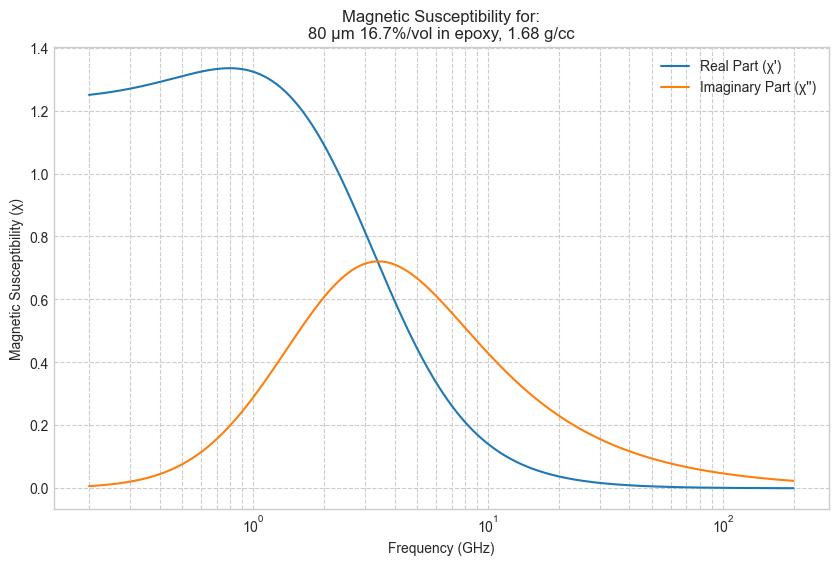

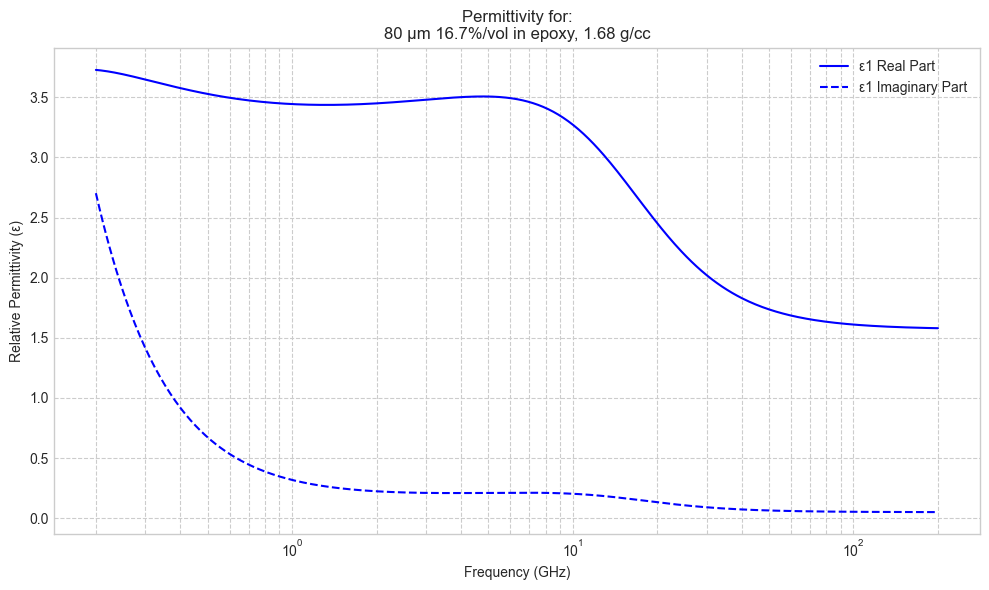

In [23]:
material = input('Enter a material: ')
user_f_min = input('Enter a minimum frequency')
user_f_max = input('Enter a maximum frequency')

# Try each function

try:
    print('try 1')
    (epsilon_f, mu_f) = getEpAndMu_12_1(user_f_min, user_f_max, material)
    print(epsilon_f)
    print(mu_f)
except:
    try:
        print('try 2')
        (epsilon_f, mu_f) = getEpAndMu_12_6(user_f_min, user_f_max, material)
        print(epsilon_f)
        print(mu_f)
    except:
        try:
            print('try 3')
            (epsilon_f, mu_f) = getEpAndMu_12_7(user_f_min, user_f_max, material)
            print(epsilon_f)
            print(mu_f)
        except:
            try:
                print('try 4')
                (epsilon_f, mu_f) = getEpAndMu_12_8(user_f_min, user_f_max, material)
                print(epsilon_f)
                print(mu_f)
            except:
                if(material=='12_4'):
                    getEpAndMu_12_4()
                else:
                    print('Material not found')